In [1]:
# Loding nav, benchmark and scheme performance datasets.

import pandas as pd
import numpy as np

from scipy.stats import linregress

import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

benchmark = pd.read_csv(
    "../data/processed/benchmark_indices_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

In [2]:
# Daily Returns 

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

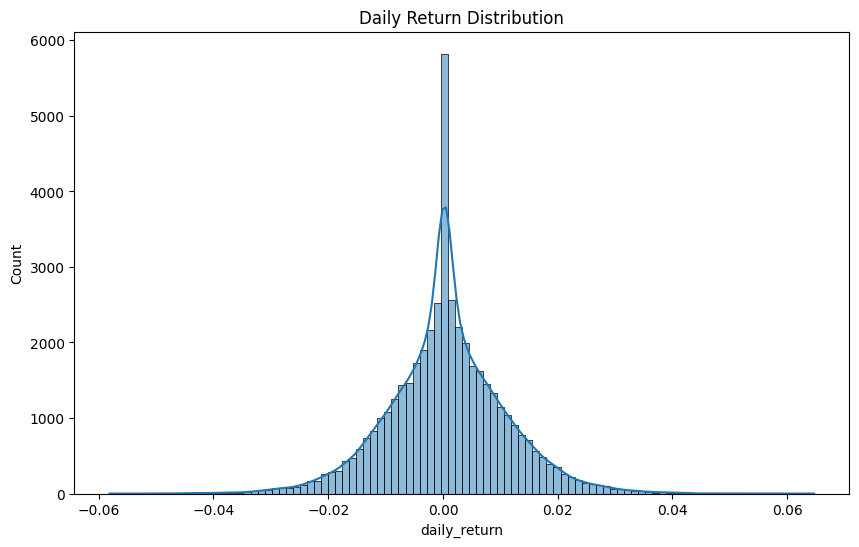

In [3]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"],
    bins=100,
    kde=True
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

In [4]:
# CAGR ( Compound Annual growth rate )
def calculate_cagr(start_nav,end_nav,years):

    return (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    )

In [6]:
# Compute fund CARG
cagr_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (
        group["date"].max()
        -
        group["date"].min()
    ).days / 365

    cagr = calculate_cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_results.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code","cagr"]
)

In [7]:
# Sharpe RATIO

RF = 0.065
sharpe_results = []

for code, group in nav.groupby("amfi_code"):

    returns = (
        group["daily_return"]
        .dropna()
    )

    mean_return = returns.mean()*252

    volatility = returns.std()

    sharpe = (
        (mean_return - RF)
        /
        volatility
    ) * np.sqrt(252)

    sharpe_results.append(
        [code,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

In [8]:
# Sortino Ratio

sortino_results = []

for code, group in nav.groupby("amfi_code"):

    returns = (
        group["daily_return"]
        .dropna()
    )

    downside = (
        returns[returns < 0]
    )

    downside_std = downside.std()

    annual_return = (
        returns.mean()*252
    )

    sortino = (
        (annual_return - RF)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_results.append(
        [code,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [10]:
# Alpha & Beta
# prepare benchmark returns

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark["benchmark_return"] = (
    benchmark["close_value"]
      .pct_change()
)

In [11]:
# Regression
alpha_beta = []

for code, group in nav.groupby("amfi_code"):

    temp = pd.merge(
        group,
        benchmark[
            ["date",
             "benchmark_return"]
        ],
        on="date"
    )

    temp = temp.dropna()

    if len(temp) < 30:
        continue

    slope, intercept, r, p, stderr = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    alpha = intercept * 252

    beta = slope

    alpha_beta.append(
        [code,alpha,beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

In [12]:
# Saving alpha beta file
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [13]:
# Maximum Drawdown 

dd_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    running_max = (
        group["nav"]
        .cummax()
    )

    drawdown = (
        group["nav"]
        /
        running_max
        -
        1
    )

    max_dd = drawdown.min()

    dd_results.append(
        [code,max_dd]
    )

drawdown_df = pd.DataFrame(
    dd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [14]:
# Fund Scorecard
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(alpha_beta_df)
    .merge(drawdown_df)
    .merge(
        performance[
            [
                "amfi_code",
                "expense_ratio_pct"
            ]
        ]
    )
)

In [15]:
# Create ranks

scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(
        ascending=False
    )
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(
        ascending=False
    )
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(
        ascending=False
    )
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        ascending=True
    )
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        ascending=False
    )
)

In [16]:
# Fund Score 
scorecard["fund_score"] = (

      scorecard["return_rank"]*0.30

    + scorecard["sharpe_rank"]*0.25

    + scorecard["alpha_rank"]*0.20

    + scorecard["expense_rank"]*0.15

    + scorecard["dd_rank"]*0.10

)

In [17]:
scorecard["fund_score"] = (

    100
    *
    (
        scorecard["fund_score"]
        /
        scorecard["fund_score"].max()
    )

)

In [18]:
# saving fund scorecard

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [19]:
# BenchMark Comparision

top5 = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)
)

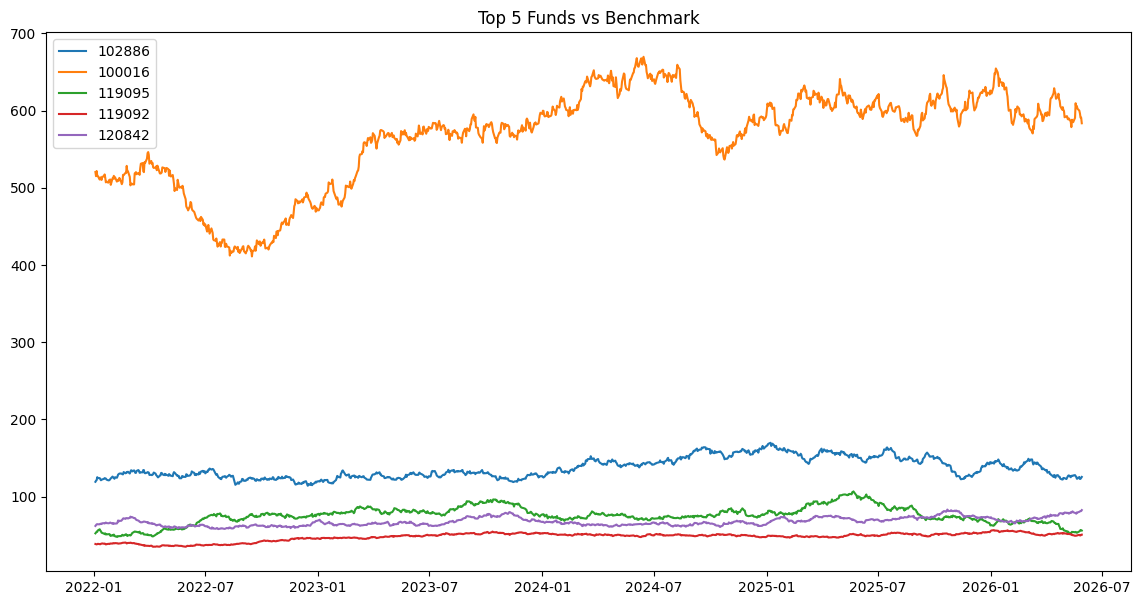

In [22]:
plt.figure(
    figsize=(14,7)
)

for code in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.legend()

plt.title(
    "Top 5 Funds vs Benchmark"
)
plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=700,
    bbox_inches="tight"
)
plt.show()